> **Data required:** This notebook uses InSight HP³ data from Spohn et al. (2024). 
> If you haven't already, download the datasets from [FigShare](https://doi.org/10.6084/m9.figshare.25099754) 
> and place them in `resources/data/`. See [`resources/data/README.md`](../resources/data/README.md) for details.

In [3]:
from PIL import Image

import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
from jax import random, grad, jit, vmap
import openpyxl
import optax

import jax.numpy as jnp

import copy

# Problem parameters
kappa = 3.93e-8       # thermal diffusivity [m^2/s]
z_0 = 0.017         # top of mole
sol_seconds = 88775.244  # one sol [s]

avg_bottom_temp = 225.6  # average bottom temperature (K)

# TEM-A Sol 1202 = mole temperature over one sol (the warmest sol sampled)
# RAD Sol 511   = surface temperature from radiometer (Spohn's proxy for sol 1202)

wb_diurnal = openpyxl.load_workbook(
    '../../resources/data/Mars Soil Temperatures and Thermal Properties from Diurnal Wave data.xlsx',
    data_only=True
)

# --- Mole temperature (TEM-A Sol 1202) ---
ws_tem = wb_diurnal['TEM-A Sol 1202']
ltst_mole, temp_mole = [], []
for row in ws_tem.iter_rows(min_row=2, values_only=True):
    # Column index 6 = 'LTST Conversion step 2' (hours, 0-24)
    # Column index 7 = 'average T15, T16' (Kelvin)
    ltst_val = row[6]
    temp_val = row[7]
    if ltst_val is not None and temp_val is not None:
        try:
            t = float(ltst_val)
            T = float(temp_val)
            if 0 <= t <= 24 and 200 < T < 260:
                ltst_mole.append(t)
                temp_mole.append(T)
        except (ValueError, TypeError):
            pass


# --- Surface temperature (RAD Sol 511) ---
ws_rad = wb_diurnal['RAD SOL 511 D']
ltst_surf, temp_surf = [], []
for row in ws_rad.iter_rows(min_row=2, values_only=True):
    # Column index 4 = 'LTST converted' (hours)
    # Column index 5 = 'FOV 2 Temperature converted' (Kelvin)
    try:
        t = float(row[4])
        T = float(row[5])
        if 0 <= t <= 24 and 150 < T < 350:
            ltst_surf.append(t)
            temp_surf.append(T)
    except (ValueError, TypeError):
        pass

# Sort surface data by LTST (it may not be in order)
sorted_surf = sorted(zip(ltst_surf, temp_surf))
ltst_surf = [x[0] for x in sorted_surf]
temp_surf = [x[1] for x in sorted_surf]

# Conversion from hours to seconds for the time points. Make sure it is mapped correctly to the Mars sol time (0-88775.244 seconds)
ltst_mole = [t * sol_seconds / 24 for t in ltst_mole]
ltst_surf = [t * sol_seconds / 24 for t in ltst_surf]


# 1. Boundary Condition points (552 points each edge as we have 552 time points in the surface data)
n_surface = len(ltst_surf)  # Should be 552

# Surface boundary (x=0):
t_bc_surface = jnp.array(ltst_surf).reshape(-1, 1)  # (552, 1)
x_bc_surface = jnp.zeros((n_surface, 1))  # (552, 1)

u_bc_surface = jnp.array(temp_surf).reshape(-1, 1)  # (552, 1)


# Combine them:
t_bc = jnp.concatenate([t_bc_surface])
x_bc = jnp.concatenate([x_bc_surface])
u_bc = jnp.concatenate([u_bc_surface])


# 2. Physics collocation points (100 * 100 = 10,000 points)
key = random.PRNGKey(0)
key1, key2 = random.split(key)
t_physics = random.uniform(key1, (10000, 1), minval=0, maxval=sol_seconds)
x_physics = random.uniform(key2, (10000, 1), minval=0, maxval=z_0)


# 3. Data points for Data Loss (5550 points)
# We can use the mole temperature data as additional data points inside the domain (not just at the boundaries). This will help guide the network to learn the correct solution.

t_data = jnp.array(ltst_mole).reshape(-1, 1)
x_data = jnp.ones((len(ltst_mole), 1)) * z_0  # Mole is at depth z_0
u_data = jnp.array(temp_mole).reshape(-1, 1)


# Normalise the data so the network only sees values of order 1. This helps with training stability and convergence. We will need to un-normalise the predictions later to compare with the original data.

# Normalisation parameters
t_min, t_max = 0.0, sol_seconds
x_min, x_max = 0.0, z_0
u_min, u_max = 185.0, 300.0  # Based on the range of temperatures in the data

def normalize_t(t): return ( t - t_min) / (t_max - t_min)
def normalize_x(x): return ( x - x_min) / (x_max - x_min)
def normalize_u(u): return ( u - u_min) / (u_max - u_min)

def unnormalize_u(u_norm): return u_norm * (u_max - u_min) + u_min

# Normalize all data
t_bc = normalize_t(t_bc)
x_bc = normalize_x(x_bc)
u_bc = normalize_u(u_bc)

t_physics = normalize_t(t_physics)
x_physics = normalize_x(x_physics)

t_data = normalize_t(t_data)
x_data = normalize_x(x_data)
u_data = normalize_u(u_data)

#Normalize kappa as well (since it appears in the physics residual)
kappa_eff = kappa * (t_max - t_min) / ((x_max - x_min)**2)  # Effective diffusivity in normalized space


# Neural Network

def init_network_params(layer_sizes, key):
    """
    Initialize parameters for a fully connected network.
    
    Args:
        layer_sizes: List of layer sizes, e.g., [2, 32, 32, 32, 1]
                    (input_dim, hidden1, hidden2, hidden3, output_dim)
        key: JAX random key for initialization
        
    Returns:
        params: List of dictionaries, each containing 'w' and 'b'
    """
    # Split random key for each layer
    keys = random.split(key, len(layer_sizes))
    
    params = []
    for i in range(len(layer_sizes) - 1):
        n_in = layer_sizes[i]
        n_out = layer_sizes[i + 1]
        
        # Split key for weights and biases
        w_key, b_key = random.split(keys[i])
        
        # Xavier initialization for weights
        params.append({
            'w': random.normal(w_key, (n_in, n_out)) * jnp.sqrt(2.0 / n_in),
            'b': jnp.zeros(n_out)
        })
    
    return params


def network(params, x):
    """
    Forward pass through the network.
    
    Args:
        params: List of layer parameters (from init_network_params)
        x: Input array, shape (batch_size, input_dim)
        
    Returns:
        Output array, shape (batch_size, output_dim)
    """
    # Process all hidden layers (all but last)
    for layer in params[:-1]:
        # Linear transformation: x @ W + b
        x = jnp.dot(x, layer['w']) + layer['b']
        # Activation function
        x = jnp.tanh(x)
    
    # Output layer (no activation)
    final_layer = params[-1]
    x = jnp.dot(x, final_layer['w']) + final_layer['b']
    
    return x


# Calculate Residual

def physics_residual_single(params, t_point, x_point, kappa_eff):

    def u(t_val, x_val):
        tx_in = jnp.array([[t_val, x_val]])
        return network(params, tx_in)[0, 0]
    
    du_dt = grad(u, argnums=0)(t_point, x_point)

    d2u_dx2 = grad(grad(u, argnums = 1), argnums=1)(t_point, x_point)

    return du_dt / kappa_eff - d2u_dx2


# Vectorize to handle all physics points at once
# So vmap will call physics_residual_single 10000 times, once for each (t, x) pair, keeping params and kappa_eff fixed.
physics_residual_batch = vmap(physics_residual_single, in_axes=(None, 0, 0, None))


# Initialize network
key = random.PRNGKey(123)
layer_sizes = [2, 64, 64, 64, 64, 1]  # 2 inputs (t, x), 1 output (u)
params = init_network_params(layer_sizes, key)

# Initialize optimizer
learning_rate = 1e-3
schedule = optax.piecewise_constant_schedule(init_value=learning_rate, boundaries_and_scales={60000: 0.1})
optimizer = optax.adam(learning_rate)
opt_state = optimizer.init(params)


@jit
def update_step(params, opt_state,
                t_bc, x_bc, u_bc, t_physics, x_physics, kappa_eff, t_data, x_data, u_data):

    def loss_fn(params):
        
        # 1. Boundary Condition Loss
        tx_bc = jnp.concatenate([t_bc, x_bc], axis=1)
        u_pred_bc = network(params, tx_bc)
        bc_loss = jnp.mean((u_pred_bc - u_bc)**2)
        
        # 2. Physics Loss
        physics_residuals = physics_residual_batch(params, 
                                                t_physics.ravel(), # (10000,) not (10000, 1)
                                                x_physics.ravel(), # (10000,) not (10000, 1)
                                                kappa_eff)
        physics_loss = jnp.mean(physics_residuals**2) # Physics residual is of 10000 points.

        # 3. Data Loss
        tx_data = jnp.concatenate([t_data, x_data], axis=1)
        u_pred_data = network(params, tx_data)
        data_loss = jnp.mean((u_pred_data - u_data)**2)
        
        return  bc_loss + physics_loss + data_loss * 100, (bc_loss, physics_loss, data_loss)
    
        # Compute loss and gradients
    (loss_val, individual_loss), grads = jax.value_and_grad(loss_fn, has_aux=True)(params)
    
    # Update parameters
    updates, new_opt_state = optimizer.update(grads, opt_state, params)
    new_params = optax.apply_updates(params, updates)
    
    return new_params, new_opt_state, loss_val, individual_loss


# Training parameters
num_iterations = 120000
save_every = 150  # Save every 150 iterations
print_every = 1000

# Storage for snapshots
snapshots = []
snapshot_iterations = []

# Prepare physics points (flatten for vmap)
t_phys_flat = t_physics.ravel()
x_phys_flat = x_physics.ravel()

# Training loop
losses = []
losses_bc = []
losses_phys = []
losses_data = []
for i in range(num_iterations):
    params, opt_state, loss, individual_loss = update_step(
        params, opt_state,
        t_bc, x_bc, u_bc,
        t_phys_flat, x_phys_flat,
        kappa_eff,
        t_data, x_data, u_data
    )
    
    losses.append(loss)
    losses_bc.append(individual_loss[0])
    losses_phys.append(individual_loss[1])
    losses_data.append(individual_loss[2])


    # Save snapshot every 150 iterations
    if (i + 1) % save_every == 0:
        # Make a copy of params (important!)
        snapshots.append(copy.deepcopy(params))
        snapshot_iterations.append(i + 1)

    
    if (i + 1) % print_every == 0:
        print(f"Iteration {i+1}/{num_iterations}, Loss: {loss:.6f}")





Iteration 1000/120000, Loss: 0.059631
Iteration 2000/120000, Loss: 0.069901
Iteration 3000/120000, Loss: 0.032981
Iteration 4000/120000, Loss: 0.023990
Iteration 5000/120000, Loss: 0.016917
Iteration 6000/120000, Loss: 0.009272
Iteration 7000/120000, Loss: 0.007396
Iteration 8000/120000, Loss: 0.001601
Iteration 9000/120000, Loss: 0.001746
Iteration 10000/120000, Loss: 0.000975
Iteration 11000/120000, Loss: 0.000712
Iteration 12000/120000, Loss: 0.000590
Iteration 13000/120000, Loss: 0.000741
Iteration 14000/120000, Loss: 0.001355
Iteration 15000/120000, Loss: 0.001483
Iteration 16000/120000, Loss: 0.003804
Iteration 17000/120000, Loss: 0.000223
Iteration 18000/120000, Loss: 0.000450
Iteration 19000/120000, Loss: 0.000371
Iteration 20000/120000, Loss: 0.000301
Iteration 21000/120000, Loss: 0.000458
Iteration 22000/120000, Loss: 0.000098
Iteration 23000/120000, Loss: 0.000275
Iteration 24000/120000, Loss: 0.000090
Iteration 25000/120000, Loss: 0.000096
Iteration 26000/120000, Loss: 0.00

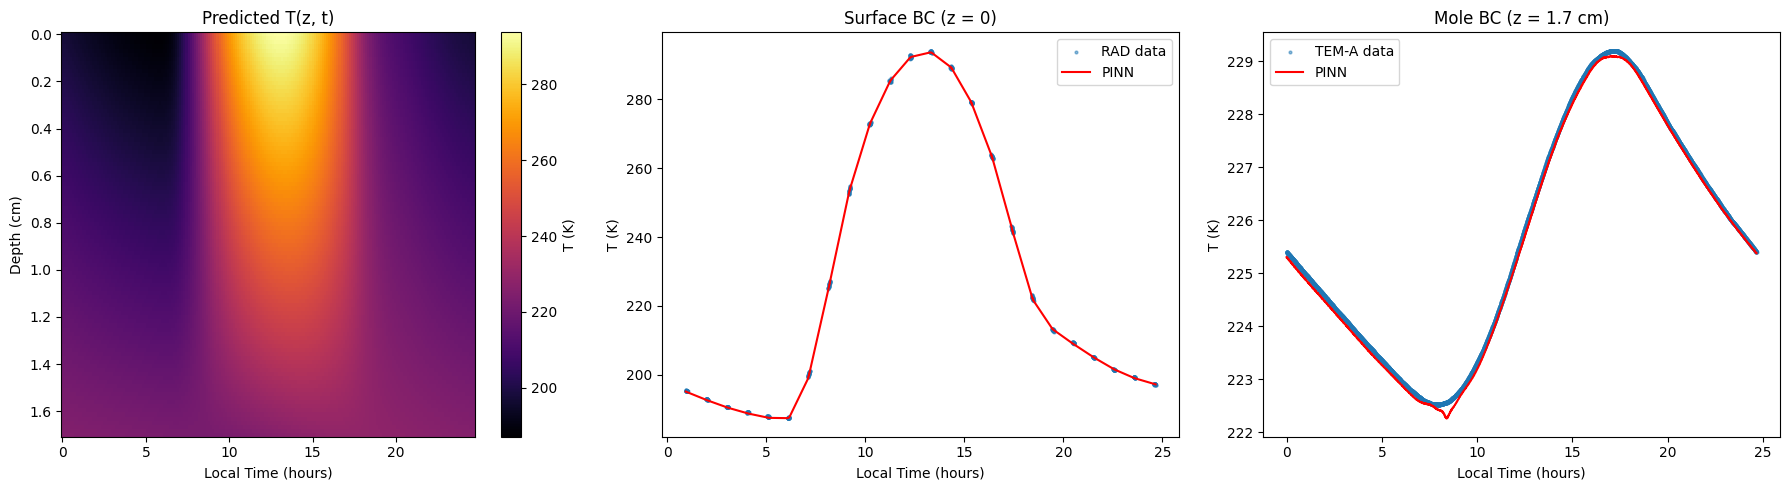

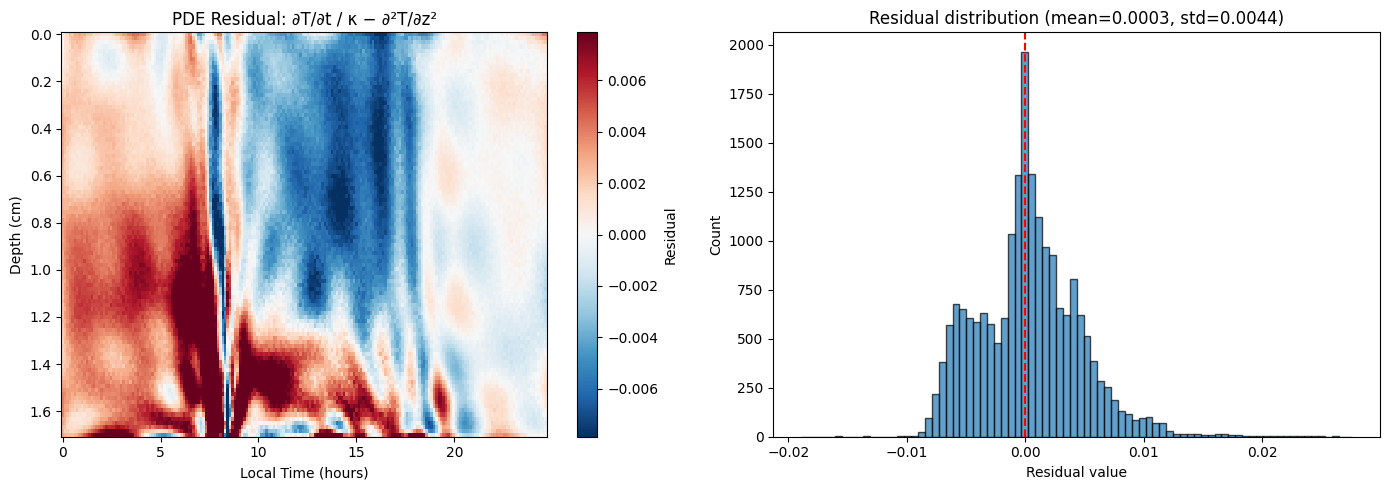

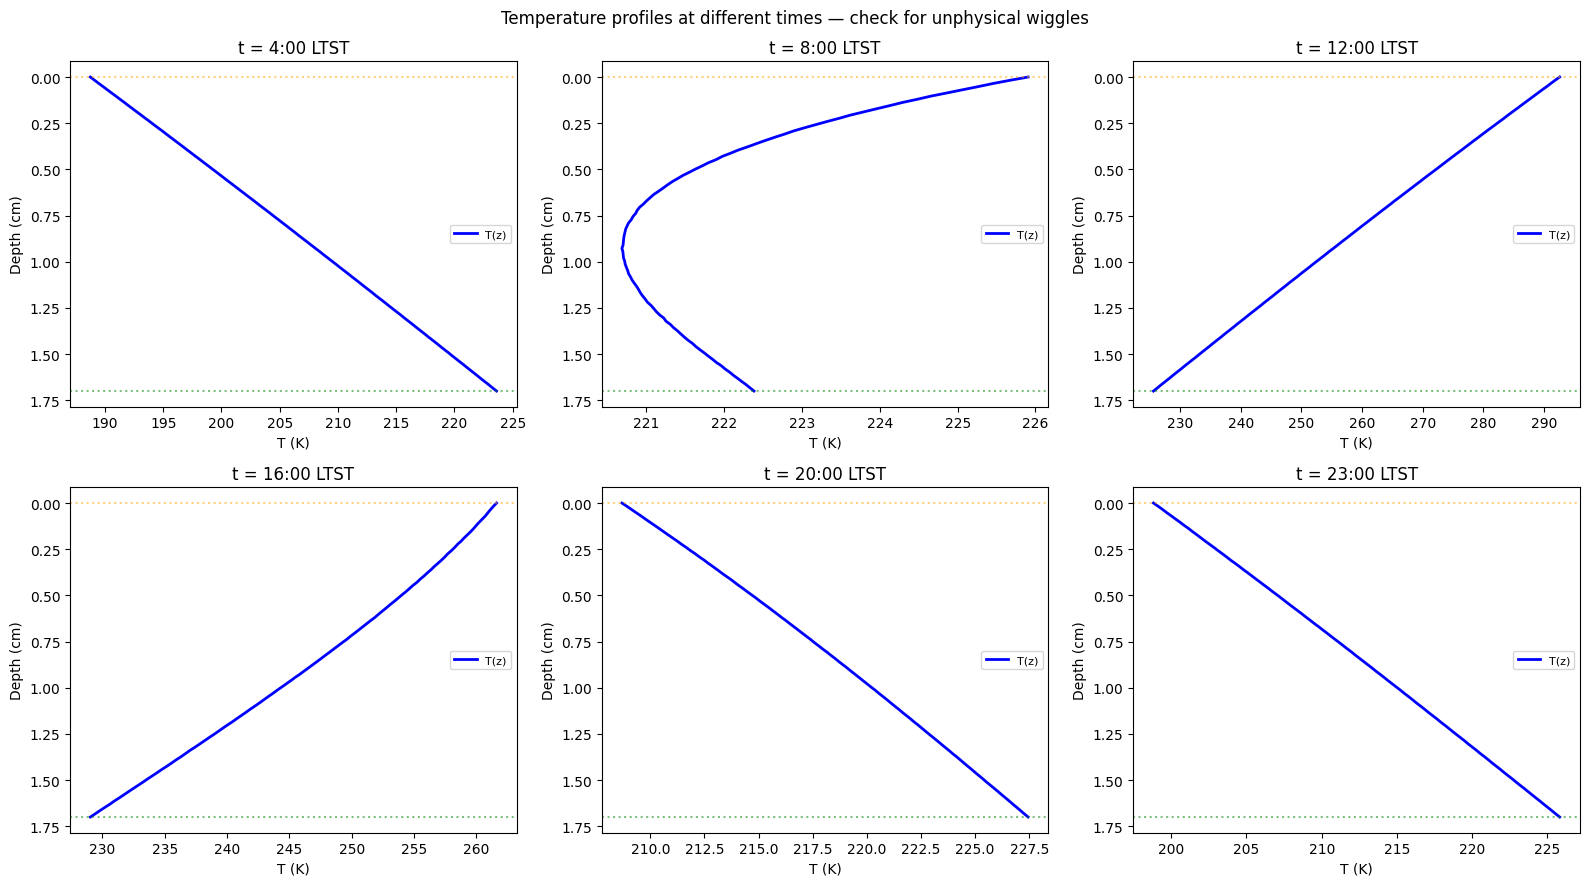

In [4]:
# ── Diagnostic: Does the PINN respect the physics? ──

# 1. Build a regular grid in NORMALISED coords
n_t, n_x = 200, 100
t_grid = jnp.linspace(0, 1, n_t)  # normalised
x_grid = jnp.linspace(0, 1, n_x)  # normalised
T_mesh, X_mesh = jnp.meshgrid(t_grid, x_grid, indexing='ij')  # (n_t, n_x)

# Flatten for network evaluation
tx_flat = jnp.stack([T_mesh.ravel(), X_mesh.ravel()], axis=1)  # (n_t*n_x, 2)

# 2. Predict T on the grid (unnormalise for plotting)
u_pred_norm = network(params, tx_flat)[:, 0]           # (n_t*n_x,)
u_pred = unnormalize_u(u_pred_norm).reshape(n_t, n_x)  # back to Kelvin

# 3. Compute PDE residual on the same grid
residuals = physics_residual_batch(
    params,
    T_mesh.ravel(),
    X_mesh.ravel(),
    kappa_eff
).reshape(n_t, n_x)

# 4. Physical axes for plotting
t_phys = t_grid * sol_seconds / 3600   # → hours
x_phys = x_grid * z_0 * 100            # → cm

# ── FIGURE 1: Temperature field + boundary fits ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) T(z, t) heatmap
im = axes[0].pcolormesh(t_phys, x_phys, u_pred.T,
                         shading='auto', cmap='inferno')
axes[0].set_xlabel('Local Time (hours)')
axes[0].set_ylabel('Depth (cm)')
axes[0].set_title('Predicted T(z, t)')
axes[0].invert_yaxis()  # depth increases downward
plt.colorbar(im, ax=axes[0], label='T (K)')

# (b) Surface BC fit (z = 0)
t_surf_hrs = jnp.array(ltst_surf) / 3600
u_surf_data = jnp.array(temp_surf)

tx_surf_check = jnp.stack([normalize_t(jnp.array(ltst_surf)),
                            jnp.zeros(len(ltst_surf))], axis=1)
u_surf_pred = unnormalize_u(network(params, tx_surf_check)[:, 0])

axes[1].scatter(t_surf_hrs, u_surf_data, s=4, alpha=0.5, label='RAD data')
axes[1].plot(t_surf_hrs, u_surf_pred, 'r-', lw=1.5, label='PINN')
axes[1].set_xlabel('Local Time (hours)')
axes[1].set_ylabel('T (K)')
axes[1].set_title('Surface BC (z = 0)')
axes[1].legend()

# (c) Mole BC fit (z = z_0)
t_mole_hrs = jnp.array(ltst_mole) / 3600
u_mole_data = jnp.array(temp_mole)

tx_mole_check = jnp.stack([normalize_t(jnp.array(ltst_mole)),
                            jnp.ones(len(ltst_mole))], axis=1)  # x_norm=1 → z=z_0
u_mole_pred = unnormalize_u(network(params, tx_mole_check)[:, 0])

axes[2].scatter(t_mole_hrs, u_mole_data, s=4, alpha=0.5, label='TEM-A data')
axes[2].plot(t_mole_hrs, u_mole_pred, 'r-', lw=1.5, label='PINN')
axes[2].set_xlabel('Local Time (hours)')
axes[2].set_ylabel('T (K)')
axes[2].set_title(f'Mole BC (z = {z_0*100:.1f} cm)')
axes[2].legend()

plt.tight_layout()
plt.savefig('diagnostic_bc_fit.png', dpi=150)
plt.show()

# ── FIGURE 2: PDE residual — the actual physics check ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) Residual heatmap
im = axes[0].pcolormesh(t_phys, x_phys, residuals.T,
                         shading='auto', cmap='RdBu_r',
                         vmin=-jnp.percentile(jnp.abs(residuals), 95),
                         vmax= jnp.percentile(jnp.abs(residuals), 95))
axes[0].set_xlabel('Local Time (hours)')
axes[0].set_ylabel('Depth (cm)')
axes[0].set_title('PDE Residual: ∂T/∂t / κ − ∂²T/∂z²')
axes[0].invert_yaxis()
plt.colorbar(im, ax=axes[0], label='Residual')

# (b) Residual histogram
axes[1].hist(residuals.ravel(), bins=80, edgecolor='k', alpha=0.7)
axes[1].set_xlabel('Residual value')
axes[1].set_ylabel('Count')
axes[1].set_title(f'Residual distribution (mean={jnp.mean(residuals):.4f}, '
                  f'std={jnp.std(residuals):.4f})')
axes[1].axvline(0, color='r', ls='--')

plt.tight_layout()
plt.savefig('diagnostic_residual.png', dpi=150)
plt.show()

# ── FIGURE 3: Time slices — most revealing for physics ──
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
slice_hours = [4, 8, 12, 16, 20, 23]

for ax, hr in zip(axes.ravel(), slice_hours):
    # Find nearest grid index
    idx = int(hr / 24 * n_t)
    idx = min(idx, n_t - 1)
    
    # Temperature profile at this time
    ax.plot(u_pred[idx, :], x_phys, 'b-', lw=2, label='T(z)')
    
    # Mark boundaries
    ax.axhline(0, color='orange', ls=':', alpha=0.5)
    ax.axhline(z_0 * 100, color='green', ls=':', alpha=0.5)
    
    ax.set_xlabel('T (K)')
    ax.set_ylabel('Depth (cm)')
    ax.set_title(f't = {hr}:00 LTST')
    ax.invert_yaxis()
    ax.legend(fontsize=8)

plt.suptitle('Temperature profiles at different times — check for unphysical wiggles')
plt.tight_layout()
plt.savefig('diagnostic_slices.png', dpi=150)
plt.show()